# Exploratory Data Analysis — Netiquette & Toxicity Corpora

This notebook documents the exploratory data analysis conducted for the thesis on
**multilabel netiquette and online toxicity classification**.
Seven independently collected corpora are harmonised into a single unified label schema
and analysed with respect to size, label distribution, text length, and inter-label
co-occurrence. The findings directly inform modelling decisions in subsequent chapters.

---

## Unified Label Schema

Following a principled schema-reduction step, all corpora are projected onto the following
**five canonical labels**:

| Label | Description | Merged from |
|---|---|---|
| `hate_speech` | Group-targeted hate speech | misogyny (GMHP7k), identity\_hate (Jigsaw) |
| `toxic` | General toxicity | severe\_toxic (Jigsaw, OR-merge) |
| `threat` | Explicit threats | — (kept as-is) |
| `insult` | Insults and personal attacks | attack (Wikipedia Attacks) |
| `impolite` | Low-politeness utterances | — (kept as-is) |

Labels that no corpus in this collection annotates (e.g. `obscene`) are **dropped entirely**.
Labels not annotated by a given corpus are stored as `NaN` — a deliberate design choice
that enables **multi-task learning with masked loss**: the loss is computed only over
labels for which a corpus provides ground truth.

---

## Corpora

| # | Dataset | Language | Domain | Format |
|---|---|---|---|---|
| 1 | Jigsaw Toxic Comment Classification | EN / multilingual | Wikipedia Talk | CSV |
| 2 | Wikipedia Personal Attacks | EN | Wikipedia Talk | CSV |
| 3 | Wikipedia Politeness Corpus | EN | Wikipedia Talk | JSONL |
| 4 | Wikipedia Detox | EN | Wikipedia Talk | TSV |
| 5 | gutefrage.net Moderation Dataset | DE | Q&A platform | Apple Numbers |
| 6 | GMHP7k — German Misogynistic Hate Speech | DE | Twitter | CSV |
| 7 | HOCON34k — German Newspaper Comments | DE | Online newspapers | CSV |

---

**Sections**
1. Dataset Loading — shape, columns, dtypes, sample rows
2. Missing Values & Label Coverage — NaN structure per corpus
3. Label Distribution — positive vs negative counts, class imbalance
4. Text Length Analysis — word-count distributions
5. Multilabel Co-occurrence — label correlation heatmaps
6. Cross-Dataset Summary — consolidated statistics table


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent          # notebooks/ → project root
DATA_DIR     = PROJECT_ROOT / 'data' / 'raw'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT))

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.facecolor':  'white',
})
sns.set_theme(style='whitegrid', palette='muted')

# 7 distinct colours — one per corpus (order matches LOADER_MAP below)
COLORS = [
    '#e05c5c',  # Jigsaw
    '#e0963c',  # WP Attacks
    '#5c9ce0',  # WP Polite
    '#8c5ce0',  # WP Detox
    '#5cbf7c',  # gutefrage
    '#e05ca0',  # GMHP7k
    '#c8b400',  # HOCON34k
]

# Short display names (corpus key → label)
SHORT = {
    'Jigsaw Toxic Comments':       'Jigsaw',
    'Wikipedia Personal Attacks':  'WP Attacks',
    'Wikipedia Politeness':        'WP Polite',
    'Wikipedia Detox':             'WP Detox',
    'gutefrage.net':               'gutefrage',
    'GMHP7k':                      'GMHP7k',
    'HOCON34k':                    'HOCON34k',
}

print('Setup complete.')
print(f'Data directory : {DATA_DIR}')
print(f'Exists         : {DATA_DIR.exists()}')


Setup complete.
Data directory : /Users/anhdang/PycharmProjects/netiquette-multilabel-classification/data/raw
Exists         : True


---
## 1. Dataset Loading

Each corpus is loaded through the project's unified loader pipeline, which handles
format differences (CSV, TSV, JSONL, Apple Numbers) and normalises all output into the
following consistent schema:

```
text | source | language | split | hate_speech | toxic | threat | insult | impolite
```

A value of `1.0` indicates a positive label; `0.0` indicates a negative label;
`NaN` indicates that the corpus does not provide an annotation for that label at all.
This three-way distinction is essential for masked multi-task learning: only non-`NaN`
labels contribute to the training loss of the corresponding output head.

> **Note on raw formats:** The Wikipedia Politeness corpus is distributed as a JSONL
> file; the gutefrage.net dataset is an Apple Numbers spreadsheet. Both are handled
> transparently by their respective loaders.


In [2]:
from src.dataset.loaders import (
    JigsawLoader,
    WikipediaAttacksLoader,
    WikipediaPolitenessLoader,
    DetoxLoader,
    GutefragLoader,
    GMHP7kLoader,
    HOCON34kLoader,
)
from src.dataset.schema import ALL_LABELS, CORPUS_LABELS, SCHEMA_COLUMNS

# Maps display name → schema source key
SOURCE_KEY = {
    'Jigsaw Toxic Comments':       'jigsaw',
    'Wikipedia Personal Attacks':  'wikipedia_attacks',
    'Wikipedia Politeness':        'wikipedia_politeness',
    'Wikipedia Detox':             'detox',
    'gutefrage.net':               'gutefrage',
    'GMHP7k':                      'gmhp7k',
    'HOCON34k':                    'hocon34k',
}

LOADER_MAP = {
    'Jigsaw Toxic Comments':       JigsawLoader(),
    'Wikipedia Personal Attacks':  WikipediaAttacksLoader(),
    'Wikipedia Politeness':        WikipediaPolitenessLoader(),
    'Wikipedia Detox':             DetoxLoader(),
    'gutefrage.net':               GutefragLoader(),
    'GMHP7k':                      GMHP7kLoader(),
    'HOCON34k':                    HOCON34kLoader(),
}

print(f'Unified schema  : {SCHEMA_COLUMNS}')
print(f'Active labels   : {ALL_LABELS}  ({len(ALL_LABELS)} total)')
print()

datasets = {}
for name, loader in LOADER_MAP.items():
    print(f'Loading {name} ...', end='  ')
    df = loader.load(DATA_DIR)
    # Verify schema contract — all loaders must produce exactly SCHEMA_COLUMNS
    assert list(df.columns) == SCHEMA_COLUMNS, f'{name}: unexpected columns {df.columns.tolist()}'
    datasets[name] = df
    print(f'{len(df):,} rows')

total = sum(len(d) for d in datasets.values())
print(f'\nTotal rows across all corpora: {total:,}')


Unified schema  : ['text', 'source', 'language', 'split', 'hate_speech', 'toxic', 'threat', 'insult', 'impolite']
Active labels   : ['hate_speech', 'toxic', 'threat', 'insult', 'impolite']  (5 total)

Loading Jigsaw Toxic Comments ...  

223,549 rows
Loading Wikipedia Personal Attacks ...  

115,864 rows
Loading Wikipedia Politeness ...  4,353 rows
Loading Wikipedia Detox ...  

159,686 rows
Loading gutefrage.net ...  

19,045 rows
Loading GMHP7k ...  7,207 rows
Loading HOCON34k ...  34,272 rows

Total rows across all corpora: 563,976


In [3]:
SEP = '─' * 65

for name, df in datasets.items():
    src_key = SOURCE_KEY[name]
    labels  = CORPUS_LABELS[src_key]

    print(SEP)
    print(f'  {name}')
    print(SEP)
    print(f'  Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'  Language   : {df["language"].unique().tolist()}')
    print(f'  Labels     : {labels}')

    split_counts = df['split'].value_counts(dropna=False)
    split_str = ', '.join(f'{k}={v:,}' for k, v in split_counts.items())
    print(f'  Splits     : {split_str}')

    # Show only the columns this corpus actually annotates
    cols = ['text', 'source', 'language', 'split'] + labels
    print()
    print('  dtypes:')
    display(df[cols].dtypes.to_frame('dtype').T)

    print('  Sample rows (text truncated to 80 chars):')
    sample = df[cols].head(3).copy()
    sample['text'] = sample['text'].str[:80] + '…'
    display(sample)
    print()


─────────────────────────────────────────────────────────────────
  Jigsaw Toxic Comments
─────────────────────────────────────────────────────────────────
  Shape      : 223,549 rows × 9 columns
  Language   : ['multilingual']
  Labels     : ['hate_speech', 'toxic', 'threat', 'insult']
  Splits     : train=159,571, test=63,978

  dtypes:


,text,source,language,split,hate_speech,toxic,threat,insult
dtype,object,object,object,object,float64,float64,float64,float64


  Sample rows (text truncated to 80 chars):


,text,source,language,split,hate_speech,toxic,threat,insult
0,Explanation\nWhy the edits made under my usern...,jigsaw,multilingual,train,0.0,0.0,0.0,0.0
1,D'aww! He matches this background colour I'm s...,jigsaw,multilingual,train,0.0,0.0,0.0,0.0
2,"Hey man, I'm really not trying to edit war. It...",jigsaw,multilingual,train,0.0,0.0,0.0,0.0



─────────────────────────────────────────────────────────────────
  Wikipedia Personal Attacks
─────────────────────────────────────────────────────────────────
  Shape      : 115,864 rows × 9 columns
  Language   : ['en']
  Labels     : ['insult']
  Splits     : train=69,526, test=23,178, dev=23,160

  dtypes:


...

,text,source,language,split,hate_speech
0,@TwitterUser Ich habe wenig Erfahrung mit Lesb...,gmhp7k,de,NaN,1.0
1,@TwitterUser Geh scheissen…,gmhp7k,de,NaN,0.0
2,@TwitterUser Baerziege wäre richtig gegendert.…,gmhp7k,de,NaN,1.0



─────────────────────────────────────────────────────────────────
  HOCON34k
─────────────────────────────────────────────────────────────────
  Shape      : 34,272 rows × 9 columns
  Language   : ['de']
  Labels     : ['hate_speech']
  Splits     : train=27,378, test=3,423, val=3,422, None=49

  dtypes:


,text,source,language,split,hate_speech
dtype,object,object,object,object,float64


  Sample rows (text truncated to 80 chars):


,text,source,language,split,hate_speech
0,Mein Motto: Leben und leben lassen ! Aber bei ...,hocon34k,de,None,1.0
1,"Aber nimmer, wenn Du auch dort bist... …",hocon34k,de,None,0.0
2,Auf meiner Party kriegst auch mal eine ab! Für...,hocon34k,de,None,1.0


---
## 2. Missing Values & Label Coverage

Two types of missingness are relevant here:

- **Null text** — rows without usable text cannot be fed to a model and are dropped during
  loading. Loaders enforce this; the count should be zero for every corpus after loading.
- **Label coverage** — each corpus annotates only a subset of the five unified labels.
  Unannotated labels are stored as `NaN` by design, **not** as `0.0`. This distinction is
  critical: a `0.0` means "the annotators judged this text to be negative for this label",
  while `NaN` means "this corpus makes no claim about this label at all". Treating `NaN`
  as `0.0` would introduce false negatives and degrade multi-task learning.

The coverage heatmap below quantifies the `NaN` rate per label per corpus (0 % = fully
annotated, 100 % = not annotated at all). A fully green column indicates that the corpus
provides labels for every row for that label; a fully red column indicates no coverage.


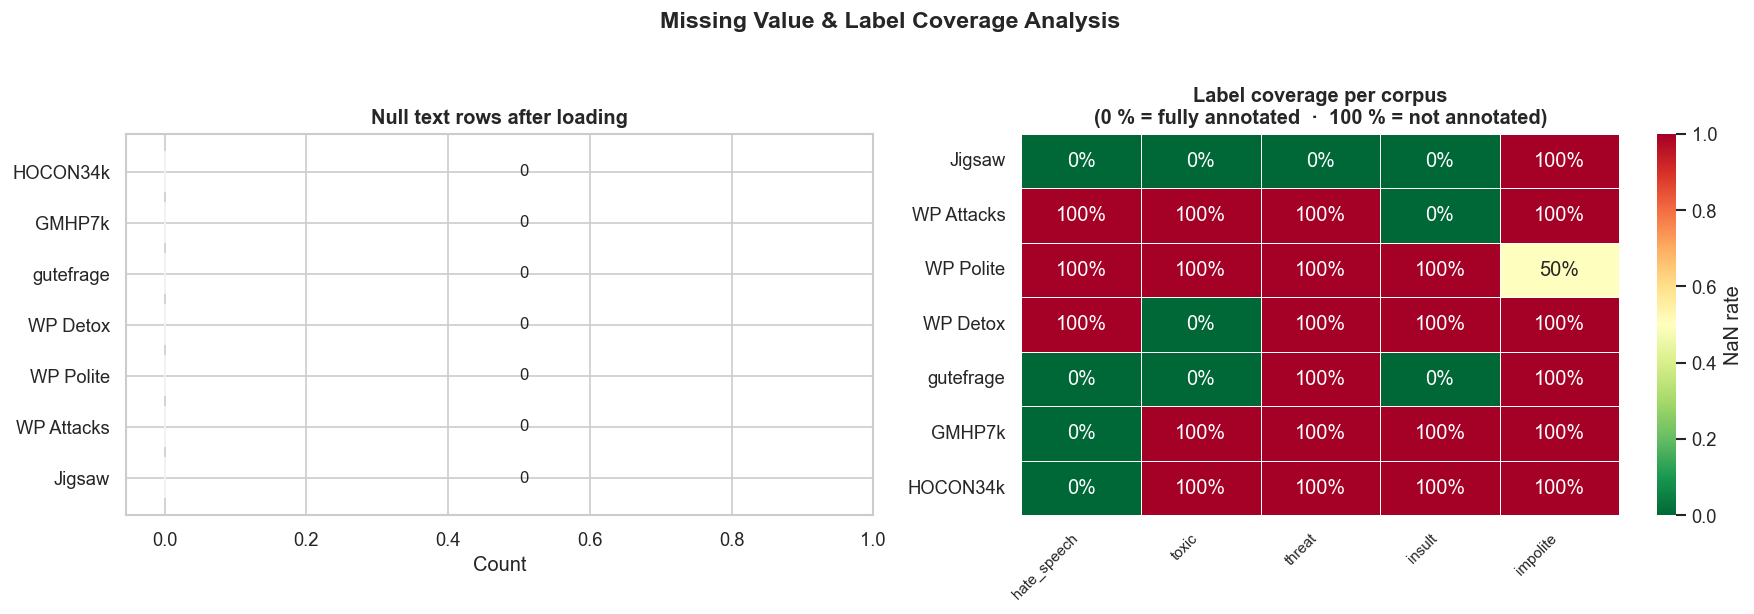

Null text counts per corpus:


,null_text_rows
Jigsaw,0
WP Attacks,0
WP Polite,0
WP Detox,0
gutefrage,0
GMHP7k,0
HOCON34k,0



Annotated rows per label (non-NaN count):


,hate_speech,toxic,threat,insult,impolite
Jigsaw,223549,223549,223549,223549,0
WP Attacks,0,0,0,115864,0
WP Polite,0,0,0,0,2178
WP Detox,0,159686,0,0,0
gutefrage,19045,19045,0,19045,0
GMHP7k,7207,0,0,0,0
HOCON34k,34272,0,0,0,0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: null text counts per corpus ────────────────────────────────────────
null_counts = pd.Series(
    {SHORT[n]: int(df['text'].isna().sum()) for n, df in datasets.items()}
)
bars = axes[0].barh(
    null_counts.index, null_counts.values,
    color=[COLORS[i] for i in range(len(null_counts))], alpha=0.85
)
axes[0].set_title("Null text rows after loading", fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_xlim(right=max(null_counts.values) * 1.3 + 1)
for bar, val in zip(bars, null_counts.values):
    axes[0].text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', fontsize=10
    )

# ── Right: NaN coverage heatmap (5-label schema) ─────────────────────────────
nan_matrix = pd.DataFrame(
    {SHORT[n]: {lbl: float(df[lbl].isna().mean()) for lbl in ALL_LABELS}
     for n, df in datasets.items()}
).T

sns.heatmap(
    nan_matrix,
    ax=axes[1],
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    annot=True, fmt='.0%',
    linewidths=0.5,
    cbar_kws={'label': 'NaN rate'},
)
axes[1].set_title(
    'Label coverage per corpus\n(0 % = fully annotated  ·  100 % = not annotated)',
    fontweight='bold'
)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.suptitle('Missing Value & Label Coverage Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_missing_values.png', bbox_inches='tight')
plt.show()

print('Null text counts per corpus:')
display(null_counts.to_frame('null_text_rows'))

print('\nAnnotated rows per label (non-NaN count):')
annotated = pd.DataFrame({
    SHORT[n]: {lbl: int(df[lbl].notna().sum()) for lbl in ALL_LABELS}
    for n, df in datasets.items()
}).T
display(annotated)


---
## 3. Label Distribution

Two complementary views of the label distribution are examined:

1. **Absolute counts** — how many positive and negative examples exist per label in each
   corpus. This determines how many supervised training signals each label head receives.
2. **Positive rate** — the fraction of annotated rows that are positive. Values below
   **10 %** indicate strong class imbalance, which typically requires mitigation during
   training (e.g. class-weighted binary cross-entropy, focal loss, or oversampling).

Severe class imbalance is an expected property of abuse-detection datasets: the vast
majority of user-generated content is benign. Any model trained without accounting for
imbalance will be biased towards predicting the majority class (negative).

> **Note:** the counts in the bar charts reflect only the annotated (non-`NaN`) rows for
> each corpus. The positive-rate plots normalise over those annotated rows only.


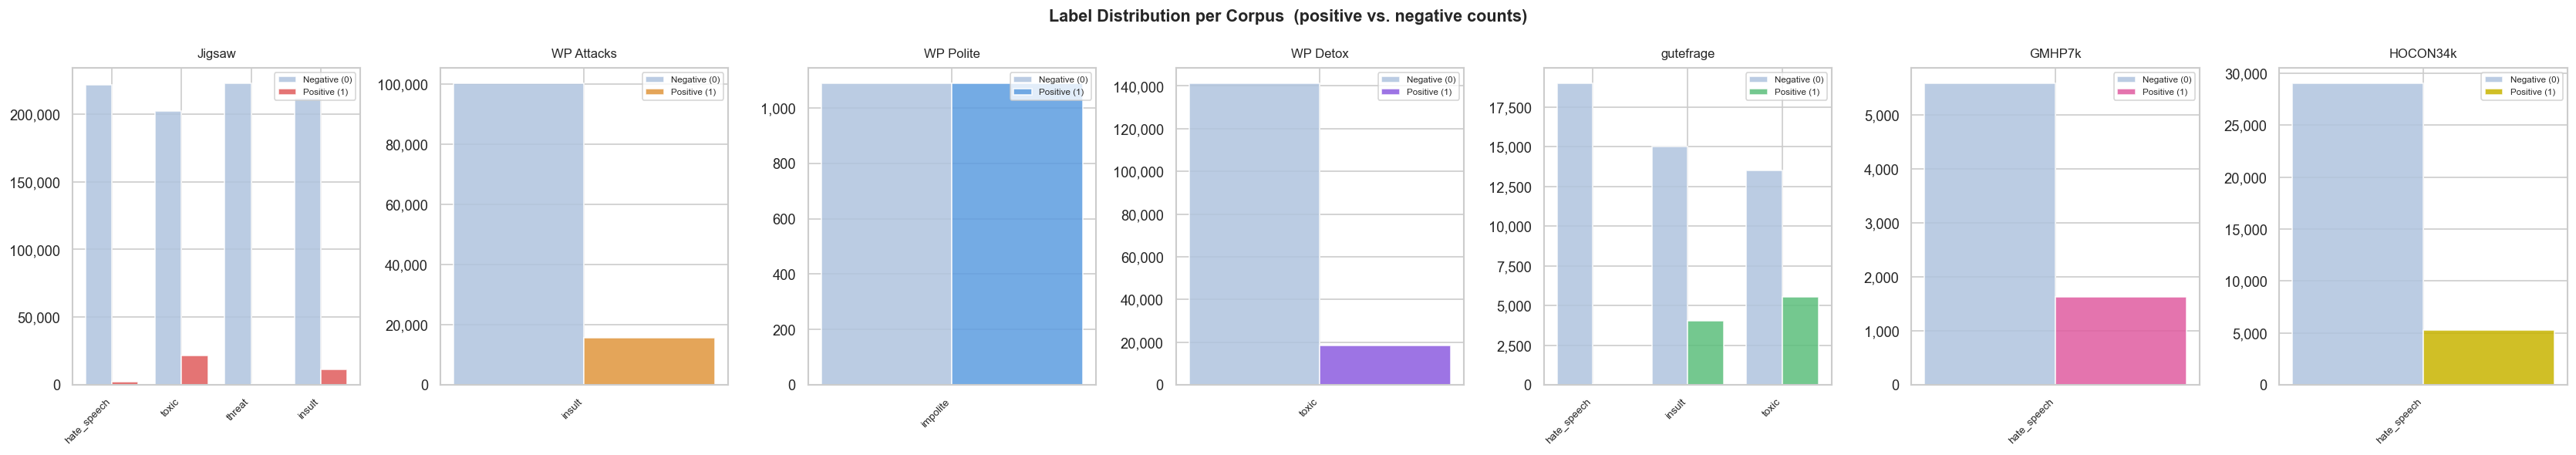

In [5]:
n_corpora = len(datasets)
fig, axes = plt.subplots(1, n_corpora, figsize=(4 * n_corpora, 5))

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    labels = CORPUS_LABELS[SOURCE_KEY[name]]
    pos    = [(df[lbl] == 1.0).sum() for lbl in labels]
    neg    = [(df[lbl] == 0.0).sum() for lbl in labels]

    x = np.arange(len(labels))
    w = 0.38
    ax.bar(x - w / 2, neg, w, label='Negative (0)', color='#b0c4de', alpha=0.85)
    ax.bar(x + w / 2, pos, w, label='Positive (1)', color=color,    alpha=0.85)

    ax.set_title(SHORT[name], fontsize=10, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{int(v):,}')
    )
    ax.legend(fontsize=7)

plt.suptitle('Label Distribution per Corpus  (positive vs. negative counts)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_label_distribution.png', bbox_inches='tight')
plt.show()


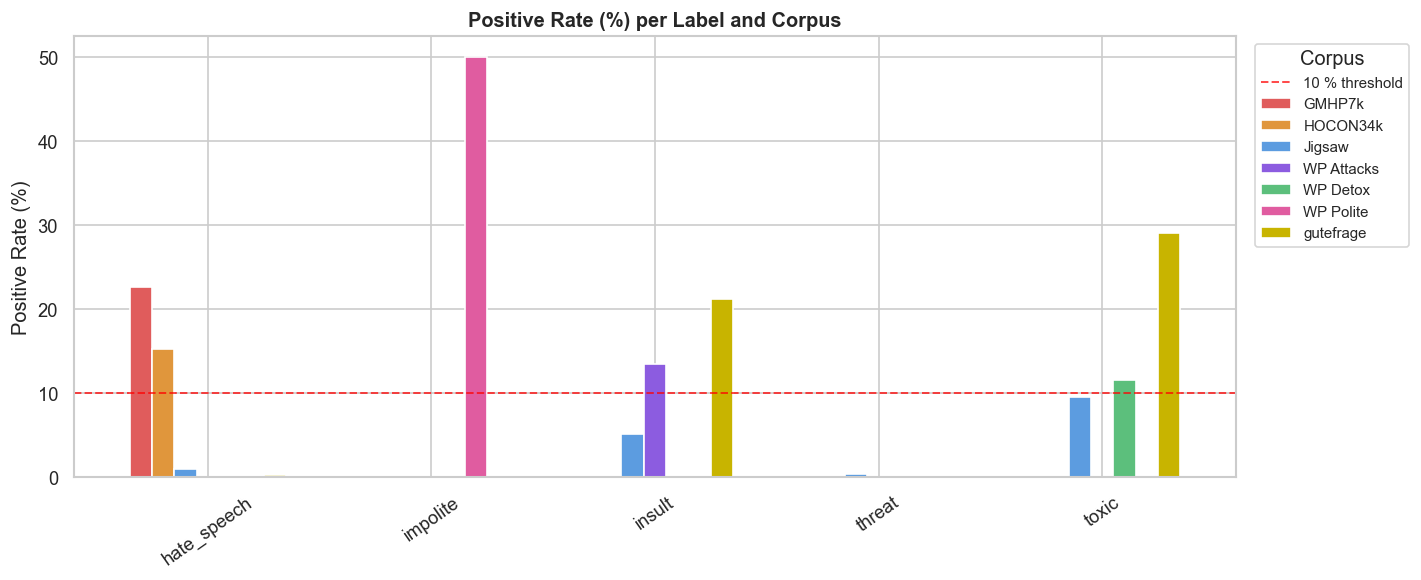

Positive rates table (%):


corpus,GMHP7k,HOCON34k,Jigsaw,WP Attacks,WP Detox,WP Polite,gutefrage
label,,,,,,,
hate_speech,22.6%,15.3%,0.9%,0.0%,0.0%,0.0%,0.2%
impolite,0.0%,0.0%,0.0%,0.0%,0.0%,50.0%,0.0%
insult,0.0%,0.0%,5.1%,13.4%,0.0%,0.0%,21.2%
threat,0.0%,0.0%,0.3%,0.0%,0.0%,0.0%,0.0%
toxic,0.0%,0.0%,9.6%,0.0%,11.5%,0.0%,29.1%


In [6]:
rate_rows = []
for name, df in datasets.items():
    for lbl in CORPUS_LABELS[SOURCE_KEY[name]]:
        total    = int(df[lbl].notna().sum())
        pos_rate = (df[lbl] == 1.0).sum() / total * 100 if total > 0 else 0.0
        rate_rows.append({'corpus': SHORT[name], 'label': lbl, 'pos_%': round(float(pos_rate), 2)})

rate_df = pd.DataFrame(rate_rows)
pivot   = rate_df.pivot(index='label', columns='corpus', values='pos_%').fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot.bar(ax=ax, rot=35, width=0.7, color=COLORS[:len(pivot.columns)])

ax.axhline(y=10, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='10 % threshold')
ax.set_title('Positive Rate (%) per Label and Corpus', fontweight='bold')
ax.set_ylabel('Positive Rate (%)')
ax.set_xlabel('')
ax.legend(title='Corpus', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_positive_rates.png', bbox_inches='tight')
plt.show()

print('Positive rates table (%):')
display(
    pivot.style
    .format('{:.1f}%')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0, vmax=40)
)


---
## 4. Text Length Distribution

The distribution of text lengths has direct implications for model input configuration:

- Standard transformer models (BERT, RoBERTa, XLM-R) impose a hard limit of **512 subword
  tokens** on input length.
- Choosing a truncation length that covers the majority of texts without excessive padding
  is a trade-off between information retention and computational cost.
- A truncation length of **128** is commonly used for short social-media texts; **256**
  accommodates the longer-tail of discussion-forum data.

Word count is used here as a proxy for subword token count. In practice, subword
tokenisation (e.g. WordPiece, BPE) produces slightly more tokens than words, particularly
for German compound words. Distributions are clipped at the **99th percentile** to
suppress extreme outliers and improve readability.


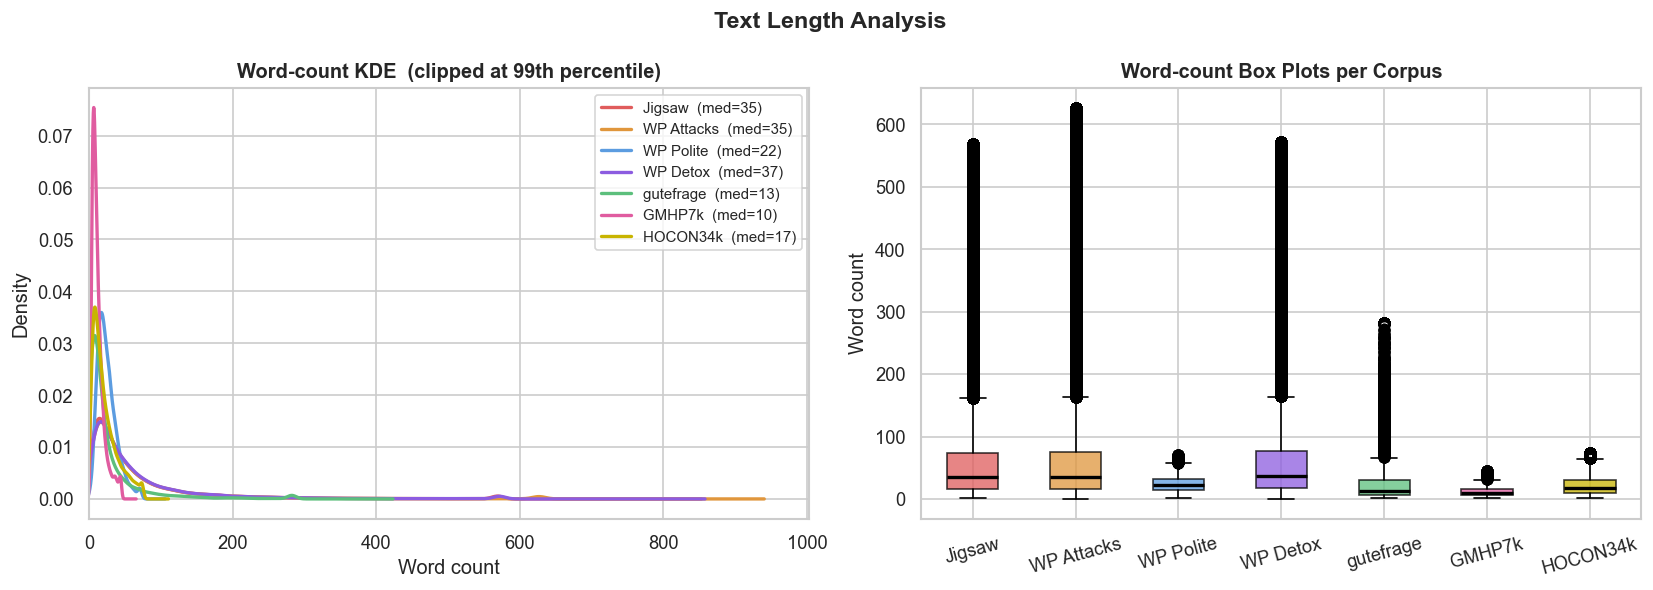

Word-count descriptive statistics:


,min,median,mean,p95,p99,max
Jigsaw,1.0,35.0,66.5,227.0,569.0,2321.0
WP Attacks,0.0,35.0,70.2,230.0,627.0,2832.0
WP Polite,1.0,22.0,25.2,51.0,71.0,133.0
WP Detox,0.0,37.0,68.2,232.0,572.0,1411.0
gutefrage,1.0,13.0,30.6,111.0,282.0,2376.0
GMHP7k,1.0,10.0,12.4,33.0,44.0,53.0
HOCON34k,1.0,17.0,22.0,60.0,74.0,94.0


In [7]:
word_counts = {
    name: df['text'].dropna().astype(str).str.split().str.len()
    for name, df in datasets.items()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── KDE ──────────────────────────────────────────────────────────────────────
for (name, wc), color in zip(word_counts.items(), COLORS):
    p99 = wc.quantile(0.99)
    wc.clip(upper=p99).plot.kde(
        ax=axes[0],
        label=f'{SHORT[name]}  (med={int(wc.median())})',
        color=color, linewidth=2
    )
axes[0].set_title('Word-count KDE  (clipped at 99th percentile)', fontweight='bold')
axes[0].set_xlabel('Word count')
axes[0].set_xlim(left=0)
axes[0].legend(fontsize=9)

# ── Box plots ─────────────────────────────────────────────────────────────────
box_data   = [wc.clip(upper=wc.quantile(0.99)).values for wc in word_counts.values()]
box_labels = [SHORT[n] for n in word_counts]
bp = axes[1].boxplot(
    box_data, labels=box_labels, patch_artist=True, notch=False,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Word-count Box Plots per Corpus', fontweight='bold')
axes[1].set_ylabel('Word count')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Text Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_text_length.png', bbox_inches='tight')
plt.show()

# ── Descriptive statistics ────────────────────────────────────────────────────
stats = pd.DataFrame({
    SHORT[name]: {
        'min':    int(wc.min()),
        'median': int(wc.median()),
        'mean':   round(float(wc.mean()), 1),
        'p95':    int(wc.quantile(0.95)),
        'p99':    int(wc.quantile(0.99)),
        'max':    int(wc.max()),
    }
    for name, wc in word_counts.items()
}).T

print('Word-count descriptive statistics:')
display(stats)


---
## 5. Multilabel Co-occurrence

When a corpus provides multiple binary labels, their co-occurrence structure reveals
whether labels tend to appear together or independently. This has implications for
the choice of loss function and model architecture:

- **High positive correlation** between two labels suggests they capture similar
  phenomena; a shared encoder representation may suffice.
- **Near-zero correlation** suggests labels are largely independent; separate output
  heads may need to be trained with distinct supervision signals.
- **Negative correlation** implies approximate mutual exclusion.

Two perspectives are provided:

1. **Jigsaw** — the only corpus in this collection that annotates four distinct labels
   (`hate_speech`, `toxic`, `threat`, `insult`) simultaneously. A lower-triangle
   Pearson correlation matrix is shown to avoid redundant information.
2. **Combined** — Pearson correlation across all five unified labels, computed over the
   full stacked dataset from all seven corpora. NaN values are excluded pairwise, so
   each cell is computed from the rows where both labels have valid annotations.

> **Interpretation note:** The combined correlation is influenced both by genuine
> semantic relationships between labels *and* by the fact that different corpora
> cover different label subsets. A high cross-label correlation in the combined
> view may partly reflect corpus-level confounding rather than a true semantic link.


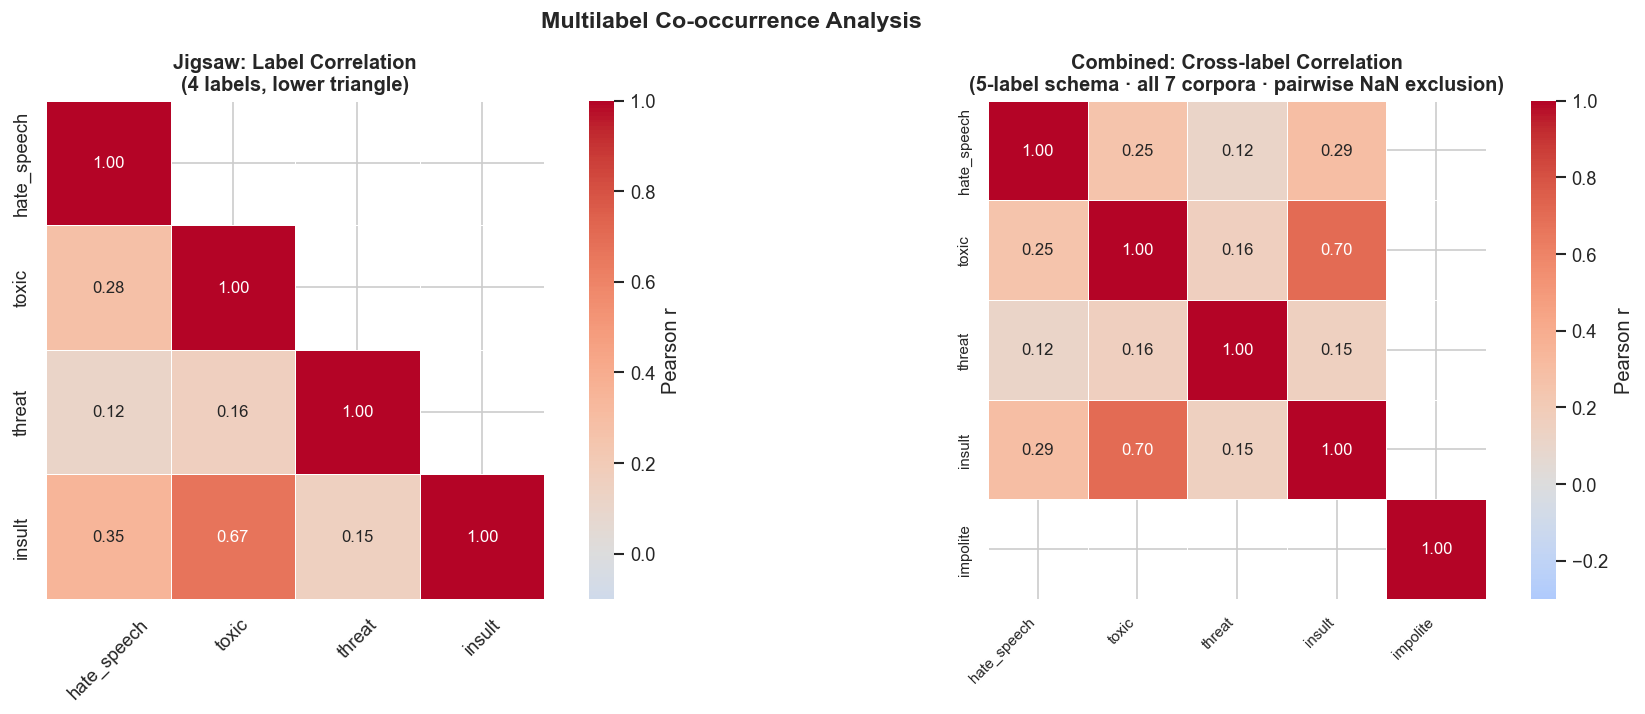

Number of rows where both labels are annotated (non-NaN) — pairwise:


,hate_speech,toxic,threat,insult,impolite
hate_speech,284073.0,242594.0,223549.0,242594.0,0.0
toxic,242594.0,402280.0,223549.0,242594.0,0.0
threat,223549.0,223549.0,223549.0,223549.0,0.0
insult,242594.0,242594.0,223549.0,358458.0,0.0
impolite,0.0,0.0,0.0,0.0,2178.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Jigsaw label correlation (4 labels: hate_speech, toxic, threat, insult) ──
jigsaw_labels = CORPUS_LABELS['jigsaw']   # sourced from schema — always current
jigsaw_data   = datasets['Jigsaw Toxic Comments'][jigsaw_labels].dropna()
jigsaw_corr   = jigsaw_data.corr()

mask_upper = np.triu(np.ones_like(jigsaw_corr, dtype=bool), k=1)
sns.heatmap(
    jigsaw_corr, ax=axes[0],
    mask=mask_upper,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-0.1, vmax=1.0,
    linewidths=0.5, square=True,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Pearson r'},
)
axes[0].set_title(
    f'Jigsaw: Label Correlation\n({len(jigsaw_labels)} labels, lower triangle)',
    fontweight='bold'
)
axes[0].tick_params(axis='x', rotation=45)

# ── Combined cross-label correlation (5-label schema, all 7 corpora) ──────────
all_data      = pd.concat([df[ALL_LABELS] for df in datasets.values()], ignore_index=True)
combined_corr = all_data.corr()

sns.heatmap(
    combined_corr, ax=axes[1],
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-0.3, vmax=1.0,
    linewidths=0.5, square=True,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Pearson r'},
)
axes[1].set_title(
    'Combined: Cross-label Correlation\n(5-label schema · all 7 corpora · pairwise NaN exclusion)',
    fontweight='bold'
)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=9)

plt.suptitle('Multilabel Co-occurrence Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_cooccurrence.png', bbox_inches='tight')
plt.show()

# ── Pairwise annotated-row overlap ────────────────────────────────────────────
print('Number of rows where both labels are annotated (non-NaN) — pairwise:')
overlap = pd.DataFrame(index=ALL_LABELS, columns=ALL_LABELS, dtype=int)
for l1 in ALL_LABELS:
    for l2 in ALL_LABELS:
        overlap.loc[l1, l2] = int(all_data[[l1, l2]].notna().all(axis=1).sum())
display(overlap)


---
## 6. Cross-Dataset Summary

The consolidated summary table below brings together the key statistics for each corpus.
Several design implications for the training pipeline follow directly from these figures:

| Concern | Implication |
|---|---|
| **Corpus size imbalance** | Jigsaw (~224 K) and Detox (~160 K) together account for over two-thirds of all rows. Small corpora (Politeness: ~4 K; GMHP7k: ~7 K) may require up-sampling or per-corpus loss weighting to prevent their signal from being drowned out. |
| **Class imbalance** | The positive rate for most labels falls well below 10 %, consistent with the observation that abusive content is a minority in naturally collected datasets. Class-weighted loss or focal loss is recommended for all label heads. |
| **Language heterogeneity** | gutefrage.net, GMHP7k, and HOCON34k are in German (~60 K rows, ~11 % of total). A multilingual encoder (e.g. XLM-R, mBERT) handles this directly; alternatively, the translation pipeline in `src/preprocessing/translate.py` can convert German rows to English before training with a monolingual model. |
| **Shared labels** | `hate_speech` is annotated by GMHP7k, HOCON34k, and gutefrage, enabling cross-corpus supervision. `toxic` is shared by Jigsaw and Detox. `insult` is shared by Jigsaw and Wikipedia Attacks. These overlaps allow the model to learn more robust representations for those labels. |
| **Split availability** | gutefrage, Wikipedia Politeness, and some GMHP7k phases (1 & 2) lack predefined train/test splits. Random stratified splits must be assigned before training. |


In [9]:
rows = []
for name, df in datasets.items():
    src_key = SOURCE_KEY[name]
    labels  = CORPUS_LABELS[src_key]

    pos_rates = []
    for lbl in labels:
        total = int(df[lbl].notna().sum())
        rate  = (df[lbl] == 1.0).sum() / total * 100 if total > 0 else 0.0
        pos_rates.append(f'{lbl}: {rate:.1f}%')

    split_info = df['split'].value_counts(dropna=True)
    split_str  = '  '.join(f'{k}: {v:,}' for k, v in split_info.items()) or 'none'
    lang       = ', '.join(df['language'].unique().tolist())
    no_split   = int((df['split'].isna() | (df['split'] == 'None')).sum())

    rows.append({
        'Dataset':           name,
        'Rows':              f'{len(df):,}',
        'Language':          lang,
        '# Labels':          str(len(labels)),
        'Labels':            ', '.join(labels),
        'Positive Rates':    '  |  '.join(pos_rates),
        'Splits (labelled)': split_str,
        'No-split rows':     f'{no_split:,}',
    })

summary = pd.DataFrame(rows).set_index('Dataset')
display(
    summary.style
    .set_properties(**{'text-align': 'left', 'font-size': '11px', 'white-space': 'pre-wrap'})
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'left'), ('background-color', '#f5f5f5'),
            ('font-weight', 'bold'), ('padding', '6px 12px')
        ]},
        {'selector': 'td', 'props': [('padding', '5px 12px')]},
    ])
)

SEP = '─' * 55
print(SEP)
print(f'Total rows       : {sum(len(d) for d in datasets.values()):,}')
print(f'Unified labels   : {ALL_LABELS}')
print(f'Label count      : {len(ALL_LABELS)}')
annotated = sum(
    1 for lbl in ALL_LABELS
    if any(df[lbl].notna().any() for df in datasets.values())
)
print(f'Labels with data : {annotated} / {len(ALL_LABELS)}')
print()

# Per-label annotated row totals (across all corpora)
print('Total annotated rows per label (across all corpora):')
label_totals = {
    lbl: sum(int(df[lbl].notna().sum()) for df in datasets.values())
    for lbl in ALL_LABELS
}
for lbl, n in label_totals.items():
    print(f'  {lbl:<15} {n:>8,}')
print(SEP)


,Rows,Language,# Labels,Labels,Positive Rates,Splits (labelled),No-split rows
Dataset,,,,,,,
Jigsaw Toxic Comments,"223,549",multilingual,4,"hate_speech, toxic, threat, insult",hate_speech: 0.9% | toxic: 9.6% | threat: 0.3% | insult: 5.1%,"train: 159,571 test: 63,978",0
Wikipedia Personal Attacks,"115,864",en,1,insult,insult: 13.4%,"train: 69,526 test: 23,178 dev: 23,160",0
Wikipedia Politeness,"4,353",en,1,impolite,impolite: 50.0%,none,"4,353"
Wikipedia Detox,"159,686",en,1,toxic,toxic: 11.5%,"train: 95,692 dev: 32,128 test: 31,866",0
gutefrage.net,"19,045",de,3,"hate_speech, insult, toxic",hate_speech: 0.2% | insult: 21.2% | toxic: 29.1%,none,"19,045"
GMHP7k,"7,207",de,1,hate_speech,hate_speech: 22.6%,"train: 5,648 test: 707 val: 706",146
HOCON34k,"34,272",de,1,hate_speech,hate_speech: 15.3%,"train: 27,378 test: 3,423 val: 3,422",49


───────────────────────────────────────────────────────
Total rows       : 563,976
Unified labels   : ['hate_speech', 'toxic', 'threat', 'insult', 'impolite']
Label count      : 5
Labels with data : 5 / 5

Total annotated rows per label (across all corpora):
  hate_speech      284,073
  toxic            402,280
  threat           223,549
  insult           358,458
  impolite           2,178
───────────────────────────────────────────────────────
